In [1]:
import torch
import pandas as pd
import numpy as np
import random
from pyfaidx import Fasta

import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [2]:
# functions

def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence


def upper_triangular_to_vector_skip_two_diagonals(matrix):
    """
    Extracts the upper triangular part of a square matrix (excluding the first two diagonals) 
    and transforms it into a vector.
    
    Parameters:
        matrix (np.ndarray): A 2D numpy matrix of shape (512, 512).
        
    Returns:
        np.ndarray: A 1D array containing the upper triangular elements (excluding the first two diagonals).
    """
    if matrix.shape != (512, 512):
        raise ValueError("Input matrix must be of shape (512, 512).")
    
    # Extract the upper triangular part excluding the first two diagonals
    upper_triangular_vector = matrix[np.triu_indices(512, k=2)]
    
    return upper_triangular_vector


def fragment_indices_in_upper_triangular(matrix_size=512, fragment_mask=None):
    """
    Given a binary mask for a fragment in a (448, 448) matrix, find the corresponding indices 
    within the upper triangular output vector (excluding the first two diagonals).

    Parameters:
        matrix_size (int): The size of the square matrix (default: 448).
        fragment_mask (np.ndarray): A boolean mask of shape (448, 448) marking the fragment.

    Returns:
        np.ndarray: Indices in the upper triangular vector corresponding to the fragment.
    """
    if fragment_mask.shape != (matrix_size, matrix_size):
        raise ValueError("Fragment mask must be of shape (448, 448).")

    # Get the upper triangular indices skipping two diagonals
    row_indices, col_indices = np.triu_indices(matrix_size, k=2)
    
    # Identify which of these indices are in the fragment
    selected_indices = np.where(fragment_mask[row_indices, col_indices])[0]
    
    return selected_indices


def store_tower_output(ohe_sequence, model, path):
    x = model.conv_block_1(ohe_sequence)
    x = model.conv_tower(x)
    # save the tensor
    torch.save(x, path)
    torch.cuda.empty_cache()

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
model = SeqNN()
# model0 
model.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/Bonev2017_mESC/models/Akita_v2_mouse_Bonev2017_mESC_model0_finetuned.pth", map_location=device))
# model1
# model.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/target_0/models/Akita_v2_mouse_target0_model1_finetuned.pth", map_location=device))
# model2
# model.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/target_0/models/Akita_v2_mouse_target0_model2_finetuned.pth", map_location=device))
# model3
# model.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/target_0/models/Akita_v2_mouse_target0_model3_finetuned.pth", map_location=device))
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [5]:
FOLD = 0

In [6]:
df = pd.read_csv(f"/scratch1/smaruj/genomic_flat_regions/flat_regions_chrom_states_tsv/fold{FOLD}_selected_genomic_windows_centered_chrom_states.tsv", sep="\t")

In [7]:
fasta_file = "/project2/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [8]:
size = 512
c = 0.5
half = size // 2

In [9]:
import numpy as np

def create_smiley_along_diagonal_value_mask(
    shape=(512, 512),
    eye_radius=10,
    mouth_radius=100,
    mouth_thickness=8,
    c=0.5
):
    """
    Create a smiley (eyes + curved mouth) whose axis of symmetry 
    is the main diagonal. The smile arc lies across the diagonal: 
    half in the upper triangle, half in the lower.

    Parameters:
    - shape: (H, W): matrix shape
    - eye_radius: radius of the eyes
    - mouth_radius: curvature radius of the smile
    - mouth_thickness: thickness of the smile
    - c: value assigned inside smiley features

    Returns:
    - mask: float32 array with 0 outside, `c` inside eyes and smile
    """
    H, W = shape
    i, j = np.meshgrid(np.arange(H, dtype=np.float32),
                       np.arange(W, dtype=np.float32), indexing='ij')
    center = np.array([H / 2, W / 2], dtype=np.float32)

    # ------------------------
    # EYES
    # ------------------------
    eye_offset = min(H, W) * 0.25
    eye1_center = center - np.array([eye_offset, 0], dtype=np.float32)
    eye2_center = eye1_center[::-1]  # mirror across diagonal

    eye1 = ((i - eye1_center[0])**2 + (j - eye1_center[1])**2) <= eye_radius**2
    eye2 = ((i - eye2_center[0])**2 + (j - eye2_center[1])**2) <= eye_radius**2

    # ------------------------
    # MOUTH (curved along diagonal)
    # ------------------------
    # Shift coordinates so (0,0) is at center
    x = i - center[0]
    y = j - center[1]

    # Rotate coordinate system by 45° so diagonal becomes horizontal
    theta = np.deg2rad(45)
    x_rot = x * np.cos(theta) - y * np.sin(theta)
    y_rot = x * np.sin(theta) + y * np.cos(theta)

    # Smile arc below "center" in rotated frame
    smile_center_y = mouth_radius / 2
    dist = np.sqrt((x_rot)**2 + (y_rot - smile_center_y)**2)

    mouth = (dist >= mouth_radius - mouth_thickness) & (dist <= mouth_radius + mouth_thickness)
    mouth &= (y_rot > 0)  # bottom half only

    # Rotate back by diagonal symmetry (no need for explicit rotation)
    mouth_mask = mouth | mouth.T  # mirror along diagonal

    # ------------------------
    # Combine
    # ------------------------
    bool_mask = (eye1 | eye2 | mouth_mask)
    value_mask = np.zeros(shape, dtype=np.float32)
    value_mask[bool_mask] = c

    return bool_mask, value_mask


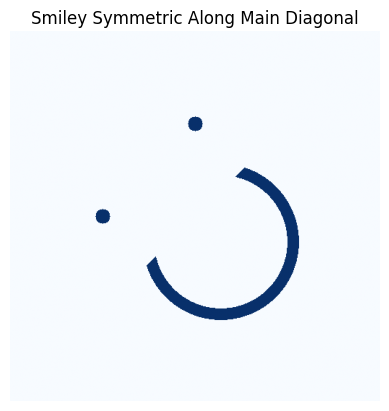

In [13]:
import matplotlib.pyplot as plt

bool_mask, value_mask = create_smiley_along_diagonal_value_mask()
plt.imshow(value_mask, cmap='Blues')
plt.axis('off')
plt.title("Smiley Symmetric Along Main Diagonal")
plt.show()

In [14]:
fragment_bool_mask, mask = create_smiley_along_diagonal_value_mask()

In [21]:
smile_mask_vector = upper_triangular_to_vector_skip_two_diagonals(mask)
smile_mask_vector_tensor = torch.tensor(smile_mask_vector).to(device)

In [15]:
smile_mask_indices = fragment_indices_in_upper_triangular(matrix_size=size, fragment_mask=fragment_bool_mask)
smile_mask_indices_tensor = torch.tensor(smile_mask_indices)

In [16]:
smile_mask_indices

array([ 53413,  53800,  53801, ..., 119723, 119865, 119866])

In [17]:
torch.save(smile_mask_indices_tensor, "/scratch1/smaruj/generate_smiley_face/smiley_face_indices.pt")

In [18]:
def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = len(batch_vectors)
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i][0,:]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [19]:
import matplotlib.pyplot as plt

In [22]:
for row in df.itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    sequence = genome[row.chrom][pred_start:pred_end]
    
    X = one_hot_encode_sequence(sequence)
    X_tensor = torch.tensor(X)
    # torch.save(X_tensor, f"/scratch1/smaruj/genomic_insertion_loci/ohe_X/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_X.pt")

    # store_tower_output(X_tensor, model, f"/scratch1/smaruj/generate_genomic_fountain/multiple_models_tower_out_fold0/model3/{chrom}_{pred_start}_{pred_end}_tower_out.pt")
    
    model.eval()
    with torch.no_grad():
        y = model(X_tensor)
    
    y = y.to(device)
    
    # summing up map + mask
    # y_bar = y[0, 0, :] + fountain_mask_vector_tensor
    # y_bar = y_bar.unsqueeze(0).unsqueeze(0)
    
    
    # replacing values of map with the mask
    y_bar = y.to(device).clone()
    masked_values = smile_mask_vector_tensor[smile_mask_indices_tensor].float()
    y_bar[0, 0, smile_mask_indices_tensor] = masked_values.to(device)
    
    torch.save(y_bar, f"/scratch1/smaruj/generate_smiley_face/targets/target_{c}/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_target.pt")